## PARTE 1 — Dataset

In [1]:
# Instalação da biblioteca MedMNIST — coleção de datasets médicos prontos para uso
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.5 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from medmnist import OrganAMNIST
from medmnist import INFO

In [4]:
# Identificador do dataset e metadados
data_flag = 'organamnist'
info = INFO[data_flag]

In [5]:
task = info['task']
n_classes = len(info['label'])
print('Classes:', info['label'])

Classes: {'0': 'bladder', '1': 'femur-left', '2': 'femur-right', '3': 'heart', '4': 'kidney-left', '5': 'kidney-right', '6': 'liver', '7': 'lung-left', '8': 'lung-right', '9': 'pancreas', '10': 'spleen'}


In [6]:
n_classes

11

In [7]:
# Download automático do dataset já dividido em treino, validação e teste
# as_rgb=True converte as imagens de escala de cinza para RGB (necessário para o DenseNet121)
train_dataset = OrganAMNIST(split='train', download=True, as_rgb=True)
test_dataset  = OrganAMNIST(split='test',  download=True, as_rgb=True)
val_dataset   = OrganAMNIST(split='val',   download=True, as_rgb=True)

100%|██████████| 38.2M/38.2M [00:02<00:00, 13.3MB/s]


In [8]:
# Separando imagens (X) e rótulos (Y) em arrays numpy
x_train = np.array([d[0] for d in train_dataset])
y_train = np.array([d[1] for d in train_dataset])

x_test = np.array([d[0] for d in test_dataset])
y_test = np.array([d[1] for d in test_dataset])

x_val = np.array([d[0] for d in val_dataset])
y_val = np.array([d[1] for d in val_dataset])

In [9]:
# Normalização: transforma pixels de 0-255 para 0-1
# Redes neurais treinam melhor com valores pequenos e normalizados
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
x_val   = x_val.astype('float32')   / 255.0

## PARTE 2 — Pipeline tf.data

In [10]:
BATCH_SIZE = 32
IMG_SIZE   = 224

# Redimensiona em batches durante o treino — evita estouro de memória da GPU
def preprocess(x, y):
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    return x, y

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.batch(BATCH_SIZE).map(preprocess).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).map(preprocess).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).map(preprocess).prefetch(tf.data.AUTOTUNE)

print('✅ Datasets prontos!')

✅ Datasets prontos!


## PARTE 3 — Por que DenseNet121?

In [11]:
# AQUI ESTOU IMPORTANDO A REDE JÁ TREINADA ----> EXTREMAMENTE IMPORTANTE
# weights='imagenet' → rede pré-treinada com +1 milhão de imagens
# include_top=False  → remove a camada final de 1000 classes do ImageNet
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## PARTE 4 — Arquitetura do modelo

In [12]:
# Congelando a parte convolucional — preserva o conhecimento do ImageNet
for layer in base_model.layers:
    layer.trainable = False

In [13]:
# Adicionando as camadas finais para classificar os 11 órgãos
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),   # Reduz o mapa de features para um vetor
    layers.Dense(128, activation='relu'),  # Camada intermediária
    layers.Dropout(0.5),               # Evita overfitting desligando 50% dos neurônios
    layers.Dense(n_classes, activation='softmax')  # Saída: probabilidade das 11 classes
])

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## PARTE 5 — Treino com backbone congelado

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 159s 121ms/step - accuracy: 0.7543 - loss: 0.7068 - val_accuracy: 0.9162 - val_loss: 0.2729
Epoch 2/5
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 101s 94ms/step - accuracy: 0.8475 - loss: 0.4252 - val_accuracy: 0.9147 - val_loss: 0.2625
Epoch 3/5
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 101s 93ms/step - accuracy: 0.8707 - loss: 0.3620 - val_accuracy: 0.9333 - val_loss: 0.2083
Epoch 4/5
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 142s 94ms/step - accuracy: 0.8821 - loss: 0.3278 - val_accuracy: 0.9387 - val_loss: 0.1932
Epoch 5/5
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 101s 93ms/step - accuracy: 0.8905 - loss: 0.3027 - val_accuracy: 0.9348 - val_loss: 0.1962


In [16]:
test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print(f"Teste - Loss: {test_loss:.4f} , Accuracy: {test_acc:.4f}")

556/556 - 55s - 99ms/step - accuracy: 0.8598 - loss: 0.3900
Teste - Loss: 0.3900 , Accuracy: 0.8598


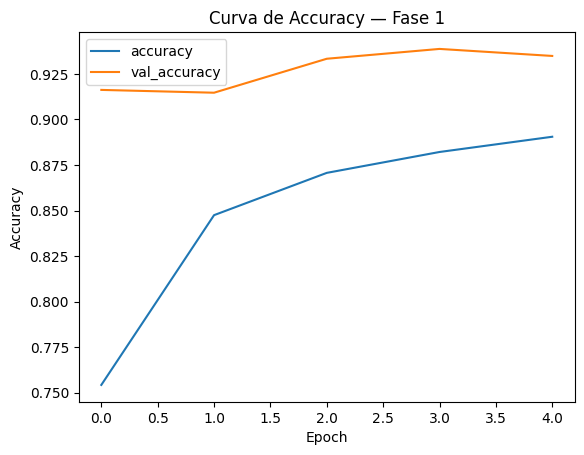

In [17]:
plt.plot(history.history['accuracy'],     label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Curva de Accuracy — Fase 1')
plt.savefig('/content/curva_accuracy_fase1.png', dpi=150, bbox_inches='tight')
plt.show()

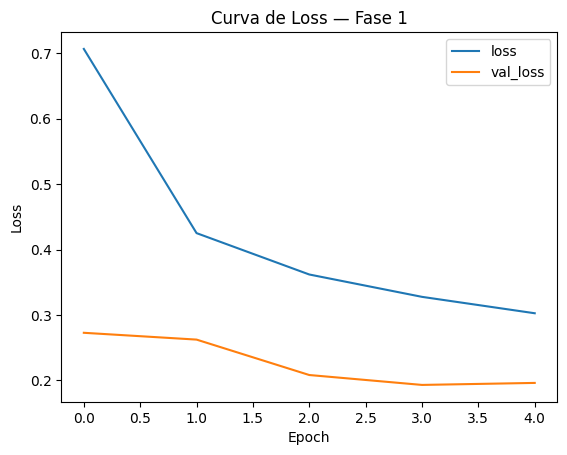

In [18]:
plt.plot(history.history['loss'],     label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Curva de Loss — Fase 1')
plt.savefig('/content/curva_loss_fase1.png', dpi=150, bbox_inches='tight')
plt.show()

## PARTE 6 — Fine-tuning

In [19]:
# TREINANDO MODELO UTILIZANDO FINE TUNING

# 1) Descongelar últimas camadas do DenseNet121
for layer in base_model.layers[:-10]:  # Congela todas menos as últimas 10
    layer.trainable = False
for layer in base_model.layers[-10:]:  # Descongela as últimas 10
    layer.trainable = True

# 2) Compilar novamente (necessário após alterar trainable)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # Menor learning rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3) Treinar novamente
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

# 4) Avaliar no teste
test_loss, test_acc = model.evaluate(test_ds)
print(f"Fine-tuning - Test Accuracy: {test_acc:.4f}")

Epoch 1/5
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 160s 124ms/step - accuracy: 0.7798 - loss: 0.9510 - val_accuracy: 0.9236 - val_loss: 0.2299
Epoch 2/5
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 103s 95ms/step - accuracy: 0.8625 - loss: 0.4313 - val_accuracy: 0.9307 - val_loss: 0.2039
Epoch 3/5
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 102s 95ms/step - accuracy: 0.8780 - loss: 0.3523 - val_accuracy: 0.9350 - val_loss: 0.1975
Epoch 4/5
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 103s 95ms/step - accuracy: 0.8907 - loss: 0.3100 - val_accuracy: 0.9362 - val_loss: 0.1916
Epoch 5/5
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 103s 95ms/step - accuracy: 0.8965 - loss: 0.2939 - val_accuracy: 0.9388 - val_loss: 0.1858
556/556 ━━━━━━━━━━━━━━━━━━━━ 52s 94ms/step - accuracy: 0.8674 - loss: 0.4048
Fine-tuning - Test Accuracy: 0.8674


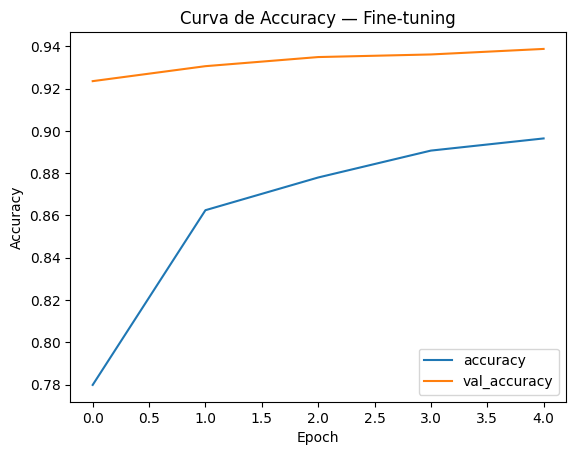

In [20]:
plt.plot(history_finetune.history['accuracy'],     label='accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Curva de Accuracy — Fine-tuning')
plt.savefig('/content/curva_accuracy_finetune.png', dpi=150, bbox_inches='tight')
plt.show()

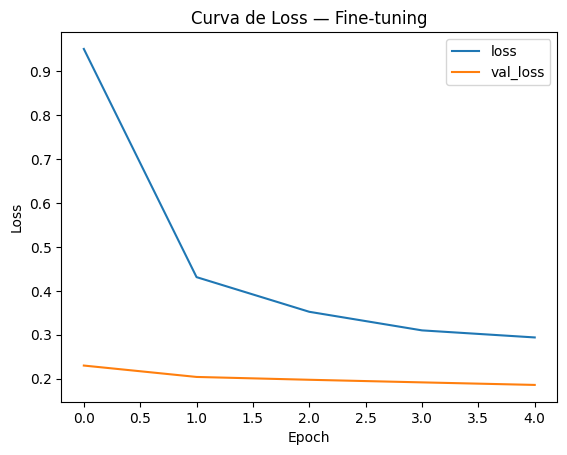

In [21]:
plt.plot(history_finetune.history['loss'],     label='loss')
plt.plot(history_finetune.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Curva de Loss — Fine-tuning')
plt.savefig('/content/curva_loss_finetune.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Salvar modelo no formato .keras
model.save('/content/CNN_Transfer_learning.keras')
print('✅ Modelo salvo: CNN_Transfer_learning.keras')

✅ Modelo salvo: CNN_Transfer_learning.keras


In [25]:
# Download de todos os arquivos gerados
from google.colab import files

files.download('/content/CNN_Transfer_learning.keras')
files.download('/content/curva_accuracy_fase1.png')
files.download('/content/curva_loss_fase1.png')
files.download('/content/curva_accuracy_finetune.png')
files.download('/content/curva_loss_finetune.png')

print('✅ Download iniciado!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download iniciado!
